In [137]:
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

In [138]:
#commented as it is needed once
#data =  "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv"

#!wget $data -O data-week-3.csv

In [139]:
df = pd.read_csv("../data/03-classifcation-homework-data.csv")
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [141]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [142]:
columns = df.columns
list(columns)

['lead_source',
 'industry',
 'employment_status',
 'location',
 'annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score',
 'converted']

In [143]:
# Identify text columns vs everything else
text_cols = df.select_dtypes(include=['object']).columns

# Fill text columns with "NA", and all remaining columns with 0.0
df[text_cols] = df[text_cols].fillna("NA")
df[df.columns.difference(text_cols)] = df[df.columns.difference(text_cols)].fillna(0.0)

/tmp/ipykernel_2671/1498907065.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


In [144]:
#recheck any null value
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

<Axes: >

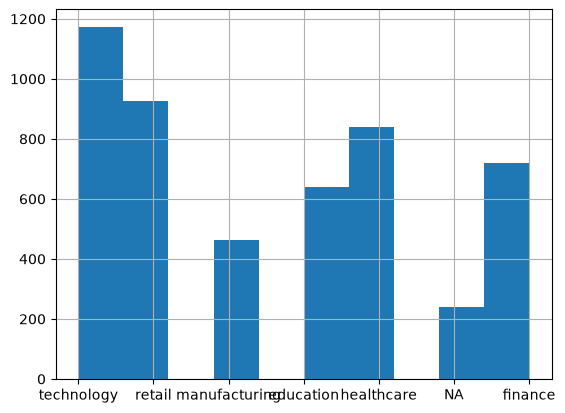

In [145]:
df.industry.hist()

In [146]:
df.industry.value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [147]:
df[df.industry== "NA"][['lead_source', 'industry']]

,lead_source,industry
12,social_media,NA
28,paid_ads,NA
30,social_media,NA
73,social_media,NA
108,social_media,NA
...,...,...
4810,organic_search,NA
4818,paid_ads,NA
4916,referral,NA
4953,referral,NA


In [148]:
# Question 2
df.select_dtypes(exclude="object").drop(columns=["converted"]).corr()

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.000000,0.161300,0.122842,0.229496
number_of_courses_viewed,0.161300,1.000000,0.721609,0.757204
interaction_count,0.122842,0.721609,1.000000,0.915746
lead_score,0.229496,0.757204,0.915746,1.000000


In [149]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
len(df_train), len(df_val), len(df_test)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   str    
 1   industry                  5000 non-null   str    
 2   employment_status         5000 non-null   str    
 3   location                  5000 non-null   str    
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [ ]:
# Question 3
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count']
# 'interaction_count' has smalletest
#numerical = ['annual_income'] 
#applying to all caegrical variable
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.converted)

mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

lead_source          0.034761
employment_status    0.020313
industry             0.002898
location             0.001050
dtype: float64

In [151]:
# Question 4
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
y_train = df_train["converted"]
print(y_train.shape)
X_train

(3000,)


array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 26))

In [ ]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [153]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val= dv.fit_transform(val_dict)
y_val = df_val["converted"]
y_pred = model.predict_proba(X_val)[:, 1]

In [154]:
#(y_pred >= 0.5).astype(int).mean()
converted_decision = (y_pred >= 0.5)

In [ ]:
#Question 6
C_values= [0.000001, 0.00001, 0.0001, 0.001]
for c in C_values:
    model_hyp = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model_hyp.fit(X_train, y_train)

    y_pred =  model_hyp.predict_proba(X_val)[:, 1]
    converted_decision = (y_pred >= 0.5)
    print(f"c {c}, {(y_val == converted_decision).mean()}")

c 1e-06, 0.601
c 1e-05, 0.601
c 0.0001, 0.601
c 0.001, 0.601


In [163]:
converted_decision

np.int64(994)

In [156]:
round((y_val == converted_decision).mean(), 2)

np.float64(0.6)

In [135]:
df_train.head()
X_n_train = df_train.drop(columns=["converted"])
X_n_train.head()
y_train.head()

4702    1
2155    0
289     1
1822    0
3442    1
Name: converted, dtype: int64

In [ ]:
#sklean full approach
#Just using this to validate my work
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
pipeline = Pipeline(
    "OneH", OneHotEncoder(sparse_output=False),
    "logistic", LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
)
pipeline.fit(X_n_train, y_train)

TypeError: Pipeline.__init__() takes 2 positional arguments but 5 were given

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 1. Identify your categorical columns automatically
# (This selects columns containing text/object types)
categorical_features = X_n_train.select_dtypes(include=["object", "category"]).columns

# 2. Build the ColumnTransformer
# 'remainder="passthrough"' ensures numeric columns are left alone and not dropped
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="passthrough",
)

# 3. Create the final Pipeline
pipeline = Pipeline(
    [
        ("prep", preprocessor),
        (
            "logistic",
            LogisticRegression(
                solver="liblinear", C=1.0, max_iter=1000, random_state=42
            ),
        ),
    ]
)

# 4. Fit the pipeline
pipeline.fit(X_n_train, y_train)


/tmp/ipykernel_2671/4219879229.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_n_train.select_dtypes(include=["object", "category"]).columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['lead_source','industry','employment_status',..., 'number_of_courses_viewed','interaction_count','lead_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [ ]:

y_pred_ = pipeline.predict_proba(df_val.drop(columns=["converted"]))[:, 1]

In [ ]:
#(y_pred >= 0.5).astype(int).mean()
converted_decision_ = (y_pred_ >= 0.5)
round((y_val == converted_decision_).mean(), 2)

np.float64(0.64)